# Упражнения <a id='tasks'></a>

Необходимо изучить библиотеку [tslearn](https://tslearn.readthedocs.io/en/stable/).

1. Взять выбранные для лабы 14 набор(ы) данных. 

3. Попробовать все методы классификации и регрессии, описанные в блоноте 14 aeon:
    Distance-based 
    Свертки (модели семейства Rocket и Hydra)
    Feature-based
    Deep Learning

    Для каждого подхода обучть не менее 3х разных моделей для классификации и регрессии.
    
     
    

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from aeon.datasets import load_classification

X_train, y_train = load_classification("GunPoint", split="TRAIN")
X_test, y_test = load_classification("GunPoint", split="TEST")

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (50, 1, 150), Test: (150, 1, 150)


Train: (50, 150, 1), Test: (150, 150, 1)


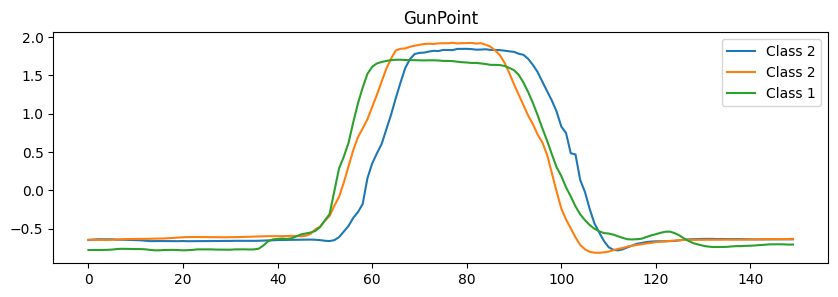

In [3]:
X_train_ts = X_train.transpose(0, 2, 1)
X_test_ts = X_test.transpose(0, 2, 1)

print(f"Train: {X_train_ts.shape}, Test: {X_test_ts.shape}")

plt.figure(figsize=(10, 3))
for i in range(3):
    plt.plot(X_train[i].squeeze(), label=f'Class {y_train[i]}')
plt.title('GunPoint')
plt.legend()
plt.show()

In [4]:
classification_results = {}

## 3 Distance-based models

In [5]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from sklearn.metrics import accuracy_score

metrics = ['euclidean', 'ctw', 'dtw']
for metric in metrics:
    model = KNeighborsTimeSeriesClassifier(n_neighbors=3, metric=metric).fit(X_train_ts, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test_ts))
    classification_results[f'KNeighborsTimeSeriesClassifier {metric}'] = accuracy
    print(f"KNeighborsTimeSeriesClassifier {metric}: {round(accuracy, 4)}")

KNeighborsTimeSeriesClassifier euclidean: 0.8733
KNeighborsTimeSeriesClassifier ctw: 0.8867
KNeighborsTimeSeriesClassifier dtw: 0.8867


## 3 Convolution-based models

In [6]:
def to_aeon_format(X):
    if X.ndim == 2:
        X = X[..., np.newaxis]
    return np.transpose(X, (0, 2, 1))

X_train_aeon = to_aeon_format(X_train_ts)
X_test_aeon = to_aeon_format(X_test_ts)

from aeon.classification.convolution_based import RocketClassifier, HydraClassifier, MiniRocketClassifier

model_classes = [MiniRocketClassifier, HydraClassifier, RocketClassifier]

for model_class in model_classes:    
    model = model_class(n_kernels=100).fit(X_train_aeon, y_train)
    accuracy = model.score(X_test_aeon, y_test)
    classification_results[f'{model_class.__name__}'] = accuracy
    print(f"{model_class.__name__}: {round(accuracy, 6)}")

MiniRocketClassifier: 0.973333
HydraClassifier: 1.0
RocketClassifier: 0.986667


## 3 Feature-based models

In [26]:
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

def ts_to_dataframe(X, y=None):
    n_samples, n_timesteps, n_features = X.shape
    rows = []
    for i in range(n_samples):
        for t in range(n_timesteps):
            row = {'id': i, 'time': t}
            for f in range(n_features):
                row[f'feature_{f}'] = X[i, t, f]
            rows.append(row)
    df = pd.DataFrame(rows)
    if y is not None:
        y_df = pd.Series(y, name='target')
        return df, y_df
    return df

In [20]:
df, y_series = ts_to_dataframe(X_train, y_train)
features = extract_features(df, column_id="id", column_sort="time")
features = impute(features)

selected_features = select_features(features, y_series)
print(f"Отобрано признаков для классификации: {len(selected_features)}")

Feature Extraction: 100%|██████████| 50/50 [02:25<00:00,  2.91s/it]
d:\Users\elise\OneDrive\Рабочий стол\Учёба\Магистратура\2 триместр\Регрессионный анализ\.venv\lib\site-packages\tsfresh\utilities\dataframe_functions.py:198: RuntimeWarning: The columns ['feature_0__mean_abs_change' 'feature_0__mean_change'
 'feature_0__mean_second_derivative_central' ...
 'feature_149__permutation_entropy__dimension_7__tau_1'
 'feature_149__query_similarity_count__query_None__threshold_0.0'
 'feature_149__mean_n_absolute_max__number_of_maxima_7'] did not have any finite values. Filling with zeros.
  warnings.warn(


Отобрано признаков для классификации: 50


In [ ]:
X_feat = features[selected_features.columns].values
X_feat_test = ts_to_dataframe(X_test)
features_test = extract_features(X_feat_test, column_id="id", column_sort="time")
features_test = impute(features_test)[selected_features.columns].values

In [25]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_feat, y_train)
y_pred_rf = rf_clf.predict(features_test)
print(f"RandomForest accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")

svm_feat_clf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_feat_clf.fit(X_feat, y_train)
y_pred_svm_feat = svm_feat_clf.predict(features_test)
print(f"SVM (kernel=rbf) accuracy: {accuracy_score(y_test, y_pred_svm_feat):.3f}")

knn_feat_clf = KNeighborsClassifier(n_neighbors=5)
knn_feat_clf.fit(X_feat, y_train)
y_pred_knn_feat = knn_feat_clf.predict(features_test)
print(f"KNN accuracy: {accuracy_score(y_test, y_pred_knn_feat):.3f}")

RandomForest accuracy: 0.867
SVM (kernel=rbf) accuracy: 0.747
KNN accuracy: 0.780


## 3 Deep learning models

In [31]:
from tslearn.neural_network import TimeSeriesMLPClassifier
activations = ['relu', 'logistic', 'tanh']
solvers = ['lbfgs', 'sgd', 'adam']

for activation, solver in zip(activations, solvers):
    model = TimeSeriesMLPClassifier(activation=activation, solver=solver).fit(X_train_ts, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test_ts))
    classification_results[f'TimeSeriesMLPClassifier with activation={activation}, solver={solver}'] = accuracy
    print(f"TimeSeriesMLPClassifier with activation={activation}, solver={solver}: {round(accuracy, 4)}")

TimeSeriesMLPClassifier with activation=relu, solver=lbfgs: 0.88
TimeSeriesMLPClassifier with activation=logistic, solver=sgd: 0.6467
TimeSeriesMLPClassifier with activation=tanh, solver=adam: 0.92


d:\Users\elise\OneDrive\Рабочий стол\Учёба\Магистратура\2 триместр\Регрессионный анализ\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Users\elise\OneDrive\Рабочий стол\Учёба\Магистратура\2 триместр\Регрессионный анализ\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


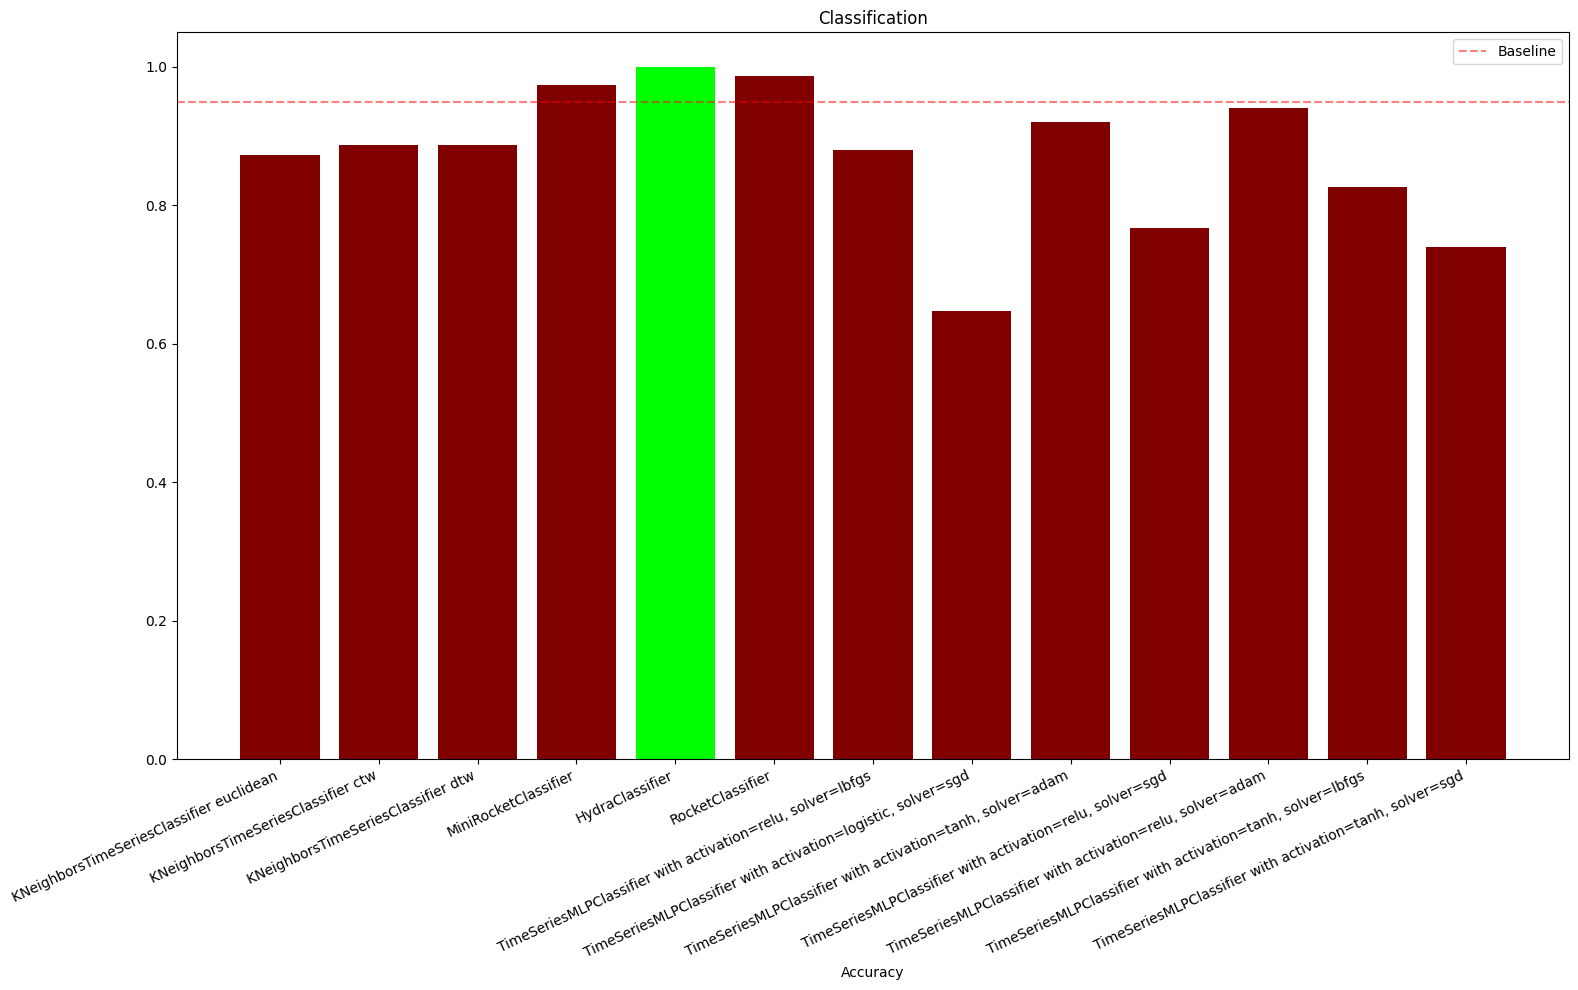

In [32]:
plt.figure(figsize=(16, 10))
accuracies = list(classification_results.values())
colors = ['lime' if acc == max(accuracies) else 'maroon' for acc in accuracies]
plt.bar(list(classification_results.keys()), accuracies, color=colors)
plt.xlabel('Accuracy')
plt.title('Classification')
plt.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='Baseline')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.legend()
plt.show()